![PIC UPV PERTE Chip Chair Logo](https://www.pic-chair.upv.es/wp-content/uploads/2024/05/logo-upv-horizontal.png)
![PIC UPV PERTE Chip Chair Logo](https://www.pic-chair.upv.es/wp-content/uploads/2024/06/logos-perte-chip-1024x119.png)


# Laboratory 2.0. Coupler Design

## 0. Imports 

### 0.1. General libraries

In [3]:
import matplotlib.pyplot as plt
import numpy as np

import tidy3d as td
import gplugins.tidy3d as gt

nm = 1e-3
wavelength = np.linspace(1500, 1600) * nm
f = td.C_0 / wavelength


### 0.2. Functions by us

In [4]:
from upvfab_design_tools import MMI_EME, DC_EME
#hay dos simuladores, uno de simulacion electromagnetica del MMIy otro del DC

In [5]:
nitride_complex = td.material_library["Si3N4"]["Luke2015PMLStable"].eps_model(f)
nitride_index, nitride_k = td.Medium.eps_complex_to_nk(nitride_complex)
box_complex = td.material_library["SiO2"]["Horiba"].eps_model(f)
box_index, box_k = td.Medium.eps_complex_to_nk(box_complex)

In [28]:
m = DC_EME()
print(dir(m))

['DC_N_waveguides', 'DC_wg_gap', 'DC_wg_width', 'EL', 'ENABLE_MMI_PLOTS', 'ENABLE_MODE_PLOTS', 'IN_WVG_positions', 'IN_WVG_slices_1D', 'IO_overlap_1D', 'IO_x_c', 'L_MMI', 'L_pi_2D', 'MMI_basis', 'MMI_modes', 'MMI_modes_pol', 'MMI_num_modes', 'MMI_width', 'OUT_WVG_positions', 'OUT_WVG_slices_1D', 'VERBOSE', 'XY', '__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', 'centers', 'dL_MMI', 'dim', 'dx_IO', 'dz', 'field_OUT', 'find_all_modes', 'find_modes', 'get_L_pi', 'intensity_z', 'io_overlaps', 'io_waveguide_mode_1D', 'io_waveguides_modes', 'io_wvg_mode', 'io_wvg_mode_1D_slice', 'io_wvg_mode_1D_x', 'mat_cladd', 'mat_core', 'mode_IN_wvg', 'mode_OUT_wvg', 'n_IN', 'n_MODES', 'n_OUT', 'name'

In [29]:
help(DC_EME)

Help on class DC_EME in module upvfab_design_tools.eme:

class DC_EME(MMI_EME)
 |  DC_EME(name='Directional Coupler', DC_N_waveguides=2, DC_wg_width=1.0, DC_wg_gap=0.8)
 |
 |  Method resolution order:
 |      DC_EME
 |      MMI_EME
 |      builtins.object
 |
 |  Methods defined here:
 |
 |  __init__(self, name='Directional Coupler', DC_N_waveguides=2, DC_wg_width=1.0, DC_wg_gap=0.8)
 |      Initialize self.  See help(type(self)) for accurate signature.
 |
 |  find_modes(self)
 |
 |  plot_propagation(self, AspectRatioOne=True)
 |
 |  ----------------------------------------------------------------------
 |  Methods inherited from MMI_EME:
 |
 |  IO_overlap_1D(self)
 |
 |  find_all_modes(self)
 |
 |  get_L_pi(self)
 |
 |  io_overlaps(self)
 |
 |  io_waveguide_mode_1D(self)
 |
 |  io_waveguides_modes(self)
 |
 |  normalize_MMI_slices_1D(self)
 |
 |  normalize_slice_1D(self)
 |
 |  output_transfer(self)
 |
 |  overlap_integral(self, s1, s2, x)
 |
 |  plot_mode_slices(self)
 |
 |  propagate

## LO.1. Directional coupler length and coupling coefficient

The total power transferred to the output is modeled using the coupling coefficient (K). This coefficient depends on the relationship between the physical length of the coupling region and the beating length:

<img src="k.png" alt="Coupling Coefficient Equation" width="400">

Simulate a directional coupler that implements two deep waveguide cores of 1.2 microns width and with a gap of 600 nm between them. 
- Plot the transfer function: K vs L/Lpi
- Comment the results: distance needed for a complete energy transfer between waveguides, distance needed for splitting power in half.. 

In [ ]:
#Calcular para un DC de esas direcciones la Lpi y hacer un vector de L, 
#para ver el ciclo de acoplo

: 

In [ ]:
# Simulation flow for Directional Couplers
# Define your geometrical parameters here
wg_gap = 0.6 # Student. Gap between waveguides #
wg_width = 1.2 # Student. Core waveguides width

d = wg_width + wg_gap
wg_N = 2

m = DC_EME() # Here you instantiate a Directional Coupler to be simulated with the Eigen-mode expansion (EME) algorithm.
m.MMI_num_modes = 12 # Number of modes to be calculated. Here, the higher, the better since we are going to calculate
                    # the propagation based on the mode decomposition. 
m.DC_wg_gap = wg_gap # Gap between waveguides
m.DC_wg_width = wg_width # Width of the waveguides core
m.DC_N_waveguides = wg_N

# 1) Compute de DC modes - Only execute whenever a geometrical parameter is changed. Takes time to find the modes. 
m.find_all_modes()

# 2) Get the L_pi 
L_pi = m.get_L_pi()
print("L_pi = ", L_pi, " µm")

L_pi = 94.02742605178396 µm
Para transferencia completa(K=1): L = L_pi = 94.02742605178396 µm
Para división  de potencia 50/50 (K=0.5): L = L_pi/2 = 47.01371302589198 µm


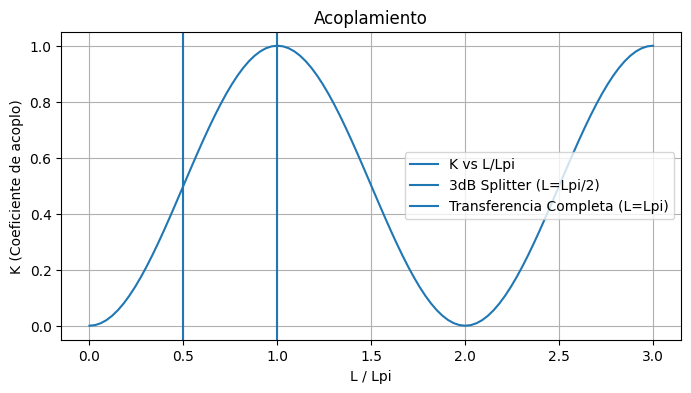

In [ ]:
L = np.linspace(0, 3 * L_pi, 100) # 2*L_pi para ver el ciclo completo de subida y bajada
K = np.sin((np.pi / 2) * (L / L_pi))**2

print(f"L_pi = {L_pi} µm")
print(f"Para transferencia completa(K=1): L = L_pi = {L_pi} µm")
print(f"Para división  de potencia 50/50 (K=0.5): L = L_pi/2 = {L_pi/2} µm")

plt.figure(figsize=(8, 4))
plt.plot(L / L_pi, K, label="K vs L/Lpi")

plt.axvline(0.5,label="3dB Splitter (L=Lpi/2)")
plt.axvline(1.0,label="Transferencia Completa (L=Lpi)")

plt.xlabel("L / Lpi")
plt.ylabel("K (Coeficiente de acoplo)")
plt.title("Acoplamiento")
plt.grid(True)
plt.legend()
plt.show()

## LO.2. 2x2 Directional Coupler

Here, you will use some functions provided by us (check **0. Imports** for more details) to simulate the propagation in a 2x2 directional coupler. Please read all the comments in the following code carefully and **make changes only to the lines marked with the #Student tag**

In [ ]:
# Simulation flow for Directional Couplers
# Define your geometrical parameters here
wg_gap = 0.6 # Student. Gap between waveguides #
wg_width = 1.2 # Student. Core waveguides width

d = wg_width + wg_gap
wg_N = 2

m = DC_EME() # Here you instantiate a Directional Coupler to be simulated with the Eigen-mode expansion (EME) algorithm.
m.MMI_num_modes = 12 # Number of modes to be calculated. Here, the higher, the better since we are going to calculate
                # the propagation based on the mode decomposition. 
m.DC_wg_gap = wg_gap # Gap between waveguides
m.DC_wg_width = wg_width # Width of the waveguides core
m.DC_N_waveguides = wg_N
# 1) Compute de DC modes - Only execute whenever a geometrical parameter is changed. Takes time to find the modes. 
m.find_all_modes()

L_pi =m.get_L_pi()

print(f"Gap: {wg_gap} um -> L_pi: {L_pi} um")


/home/mjulben/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


Gap: 0.6 um -> L_pi: 94.02742605180423 um


/home/mjulben/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/940 [00:00<?, ?it/s]

------- Pameters -------
MMI length 47.0137
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.9688
Total OUT power: 0.9583
Excess loss [dB] =  0.1851
------------------------
Power over OUTs:  ['0.4791', '0.4791']
Ratio over OUTs ['0.5000', '0.5000']
Gap: 0.6 um -> L_pi: 94.02742605180423 um


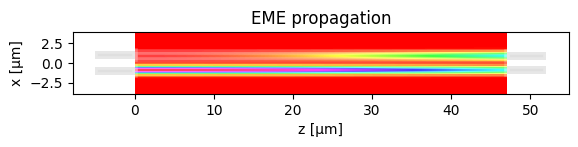

In [ ]:
# IMPORTANT!!! 
# # If you DON'T change any geometrical parameter
# (waveguide widths or gap) you can skip last cell. 
# YOU CAN RUN the lines below as many times as you wish
# (SAVES TIME)

# 3) Configure DC
# DC I/O number
m.n_IN = 2
m.n_OUT = 2

m.L_MMI = L_pi/2 # Since we use the same library for propagation simulations of MMI and DC 
                    # some variables might be identified as "MMI". Sorry about that (: 
                    # Might change in the future 

# 4) Run propagation - get power transfer and plot propagation
m.propagation()
print(f"Gap: {wg_gap} um -> L_pi: {L_pi} um")

/home/mjulben/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)
/home/mjulben/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/940 [00:00<?, ?it/s]

------- Pameters -------
MMI length 47.0137
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.9688
Total OUT power: 0.9583
Excess loss [dB] =  0.1851
------------------------
Power over OUTs:  ['0.4791', '0.4791']
Ratio over OUTs ['0.5000', '0.5000']
Gap: 0.6 um -> L_pi: 94.02742605180929 um


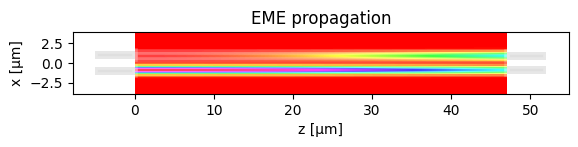

In [ ]:
#GAP = 0.6 um -> L_pi = 1.2 um

wg_gap = 0.6 
wg_width = 1.2 

d = wg_width + wg_gap
wg_N = 2

m = DC_EME() # Here you instantiate a Directional Coupler to be simulated with the Eigen-mode expansion (EME) algorithm.
m.MMI_num_modes = 12 # Number of modes to be calculated. Here, the higher, the better since we are going to calculate
                # the propagation based on the mode decomposition. 
m.DC_wg_gap = wg_gap # Gap between waveguides
m.DC_wg_width = wg_width # Width of the waveguides core
m.DC_N_waveguides = wg_N
m.find_all_modes()

L_pi =m.get_L_pi()

m.n_IN = 2
m.n_OUT = 2
m.L_MMI = L_pi/2 # Since we use the same library for propagation simulations of MMI and DC 
                    # some variables might be identified as "MMI". Sorry about that (: 
                    # Might change in the future 

# 4) Run propagation - get power transfer and plot propagation
m.propagation()
print(f"Gap: {wg_gap} um -> L_pi: {L_pi} um")

/home/mjulben/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)
/home/mjulben/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/1281 [00:00<?, ?it/s]

------- Pameters -------
MMI length 64.0328
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.9841
Total OUT power: 0.9737
Excess loss [dB] =  0.1157
------------------------
Power over OUTs:  ['0.4869', '0.4868']
Ratio over OUTs ['0.5000', '0.5000']
Gap: 0.7 um -> L_pi: 128.0656733391934 um


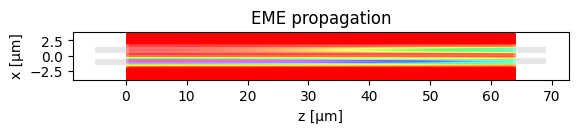

In [ ]:
#GAP = 0.7 um -> L_pi = 1.2 um

wg_gap = 0.7 
wg_width = 1.2 

d = wg_width + wg_gap
wg_N = 2

m = DC_EME() # Here you instantiate a Directional Coupler to be simulated with the Eigen-mode expansion (EME) algorithm.
m.MMI_num_modes = 12 # Number of modes to be calculated. Here, the higher, the better since we are going to calculate
                # the propagation based on the mode decomposition. 
m.DC_wg_gap = wg_gap # Gap between waveguides
m.DC_wg_width = wg_width # Width of the waveguides core
m.DC_N_waveguides = wg_N
m.find_all_modes()

L_pi =m.get_L_pi()

m.n_IN = 2
m.n_OUT = 2
m.L_MMI = L_pi/2 # Since we use the same library for propagation simulations of MMI and DC 
                    # some variables might be identified as "MMI". Sorry about that (: 
                    # Might change in the future 

# 4) Run propagation - get power transfer and plot propagation
m.propagation()
print(f"Gap: {wg_gap} um -> L_pi: {L_pi} um")

/home/mjulben/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)
/home/mjulben/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/1740 [00:00<?, ?it/s]

------- Pameters -------
MMI length 86.9819
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.9882
Total OUT power: 0.9778
Excess loss [dB] =  0.0976
------------------------
Power over OUTs:  ['0.4888', '0.4890']
Ratio over OUTs ['0.4999', '0.5001']
Gap: 0.8 um -> L_pi: 173.96389977148763 um


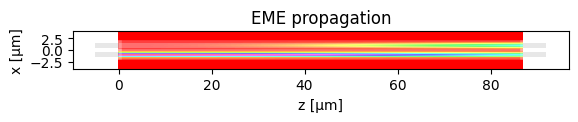

In [ ]:
#GAP = 0.8 um -> L_pi = 1.2 um

wg_gap = 0.8 
wg_width = 1.2 

d = wg_width + wg_gap
wg_N = 2

m = DC_EME() # Here you instantiate a Directional Coupler to be simulated with the Eigen-mode expansion (EME) algorithm.
m.MMI_num_modes = 12 # Number of modes to be calculated. Here, the higher, the better since we are going to calculate
                # the propagation based on the mode decomposition. 
m.DC_wg_gap = wg_gap # Gap between waveguides
m.DC_wg_width = wg_width # Width of the waveguides core
m.DC_N_waveguides = wg_N
m.find_all_modes()

L_pi =m.get_L_pi()

m.n_IN = 2
m.n_OUT = 2
m.L_MMI = L_pi/2 # Since we use the same library for propagation simulations of MMI and DC 
                    # some variables might be identified as "MMI". Sorry about that (: 
                    # Might change in the future 

# 4) Run propagation - get power transfer and plot propagation
m.propagation()
print(f"Gap: {wg_gap} um -> L_pi: {L_pi} um")

/home/mjulben/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)
/home/mjulben/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/2358 [00:00<?, ?it/s]

------- Pameters -------
MMI length 117.8870
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.9832
Total OUT power: 0.9728
Excess loss [dB] =  0.1198
------------------------
Power over OUTs:  ['0.4863', '0.4865']
Ratio over OUTs ['0.4999', '0.5001']
Gap: 0.9 um -> L_pi: 235.77407047787594 um


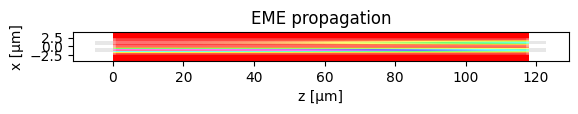

In [ ]:
#GAP = 0.9 um -> L_pi = 1.2 um

wg_gap = 0.9 
wg_width = 1.2 

d = wg_width + wg_gap
wg_N = 2

m = DC_EME() # Here you instantiate a Directional Coupler to be simulated with the Eigen-mode expansion (EME) algorithm.
m.MMI_num_modes = 12 # Number of modes to be calculated. Here, the higher, the better since we are going to calculate
                # the propagation based on the mode decomposition. 
m.DC_wg_gap = wg_gap # Gap between waveguides
m.DC_wg_width = wg_width # Width of the waveguides core
m.DC_N_waveguides = wg_N
m.find_all_modes()

L_pi =m.get_L_pi()

m.n_IN = 2
m.n_OUT = 2
m.L_MMI = L_pi/2 # Since we use the same library for propagation simulations of MMI and DC 
                    # some variables might be identified as "MMI". Sorry about that (: 
                    # Might change in the future 

# 4) Run propagation - get power transfer and plot propagation
m.propagation()
print(f"Gap: {wg_gap} um -> L_pi: {L_pi} um")

/home/mjulben/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)
/home/mjulben/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/3189 [00:00<?, ?it/s]

------- Pameters -------
MMI length 159.4421
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.9663
Total OUT power: 0.9560
Excess loss [dB] =  0.1955
------------------------
Power over OUTs:  ['0.4778', '0.4782']
Ratio over OUTs ['0.4998', '0.5002']
Gap: 1.0 um -> L_pi: 318.88415207678196 um


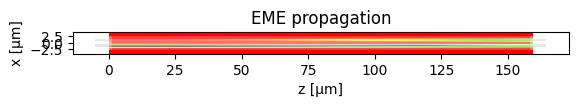

In [ ]:
#GAP = 1.0 um -> L_pi = 1.2 um

wg_gap = 1.0 
wg_width = 1.2 

d = wg_width + wg_gap
wg_N = 2

m = DC_EME() # Here you instantiate a Directional Coupler to be simulated with the Eigen-mode expansion (EME) algorithm.
m.MMI_num_modes = 12 # Number of modes to be calculated. Here, the higher, the better since we are going to calculate
                # the propagation based on the mode decomposition. 
m.DC_wg_gap = wg_gap # Gap between waveguides
m.DC_wg_width = wg_width # Width of the waveguides core
m.DC_N_waveguides = wg_N
m.find_all_modes()

L_pi =m.get_L_pi()

m.n_IN = 2
m.n_OUT = 2
m.L_MMI = L_pi/2 # Since we use the same library for propagation simulations of MMI and DC 
                    # some variables might be identified as "MMI". Sorry about that (: 
                    # Might change in the future 

# 4) Run propagation - get power transfer and plot propagation
m.propagation()
print(f"Gap: {wg_gap} um -> L_pi: {L_pi} um")

/home/mjulben/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)
/home/mjulben/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/4305 [00:00<?, ?it/s]

------- Pameters -------
MMI length 215.2738
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.9360
Total OUT power: 0.9258
Excess loss [dB] =  0.3351
------------------------
Power over OUTs:  ['0.4628', '0.4629']
Ratio over OUTs ['0.4999', '0.5001']
Gap: 1.1 um -> L_pi: 430.5476100766493 um


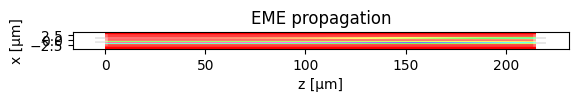

In [ ]:
#GAP = 1.1 um -> L_pi = 1.2 um

wg_gap = 1.1 
wg_width = 1.2 

d = wg_width + wg_gap
wg_N = 2

m = DC_EME() # Here you instantiate a Directional Coupler to be simulated with the Eigen-mode expansion (EME) algorithm.
m.MMI_num_modes = 12 # Number of modes to be calculated. Here, the higher, the better since we are going to calculate
                # the propagation based on the mode decomposition. 
m.DC_wg_gap = wg_gap # Gap between waveguides
m.DC_wg_width = wg_width # Width of the waveguides core
m.DC_N_waveguides = wg_N
m.find_all_modes()

L_pi =m.get_L_pi()

m.n_IN = 2
m.n_OUT = 2
m.L_MMI = L_pi/2 # Since we use the same library for propagation simulations of MMI and DC 
                    # some variables might be identified as "MMI". Sorry about that (: 
                    # Might change in the future 

# 4) Run propagation - get power transfer and plot propagation
m.propagation()
print(f"Gap: {wg_gap} um -> L_pi: {L_pi} um")

/home/mjulben/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)
/home/mjulben/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/5804 [00:00<?, ?it/s]

------- Pameters -------
MMI length 290.2147
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.8916
Total OUT power: 0.8818
Excess loss [dB] =  0.5464
------------------------
Power over OUTs:  ['0.4407', '0.4410']
Ratio over OUTs ['0.4998', '0.5002']
Gap: 1.2 um -> L_pi: 580.4293623075473 um


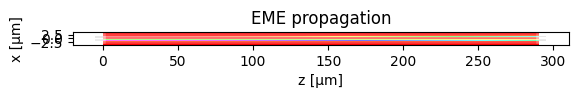

In [ ]:
#GAP = 1.2 um -> L_pi = 1.2 um

wg_gap = 1.2 
wg_width = 1.2 

d = wg_width + wg_gap
wg_N = 2

m = DC_EME() # Here you instantiate a Directional Coupler to be simulated with the Eigen-mode expansion (EME) algorithm.
m.MMI_num_modes = 12 # Number of modes to be calculated. Here, the higher, the better since we are going to calculate
                # the propagation based on the mode decomposition. 
m.DC_wg_gap = wg_gap # Gap between waveguides
m.DC_wg_width = wg_width # Width of the waveguides core
m.DC_N_waveguides = wg_N
m.find_all_modes()

L_pi =m.get_L_pi()

m.n_IN = 2
m.n_OUT = 2
m.L_MMI = L_pi/2 # Since we use the same library for propagation simulations of MMI and DC 
                    # some variables might be identified as "MMI". Sorry about that (: 
                    # Might change in the future 

# 4) Run propagation - get power transfer and plot propagation
m.propagation()
print(f"Gap: {wg_gap} um -> L_pi: {L_pi} um")

/home/mjulben/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)
/home/mjulben/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/7814 [00:00<?, ?it/s]

------- Pameters -------
MMI length 390.6951
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.8474
Total OUT power: 0.8380
Excess loss [dB] =  0.7677
------------------------
Power over OUTs:  ['0.4189', '0.4191']
Ratio over OUTs ['0.4999', '0.5001']
Gap: 1.3 um -> L_pi: 781.390139171657 um


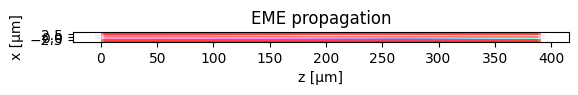

In [ ]:
#GAP = 1.3 um -> L_pi = 1.2 um

wg_gap = 1.3 
wg_width = 1.2 

d = wg_width + wg_gap
wg_N = 2

m = DC_EME() # Here you instantiate a Directional Coupler to be simulated with the Eigen-mode expansion (EME) algorithm.
m.MMI_num_modes = 12 # Number of modes to be calculated. Here, the higher, the better since we are going to calculate
                # the propagation based on the mode decomposition. 
m.DC_wg_gap = wg_gap # Gap between waveguides
m.DC_wg_width = wg_width # Width of the waveguides core
m.DC_N_waveguides = wg_N
m.find_all_modes()

L_pi =m.get_L_pi()

m.n_IN = 2
m.n_OUT = 2
m.L_MMI = L_pi/2 # Since we use the same library for propagation simulations of MMI and DC 
                    # some variables might be identified as "MMI". Sorry about that (: 
                    # Might change in the future 

# 4) Run propagation - get power transfer and plot propagation
m.propagation()
print(f"Gap: {wg_gap} um -> L_pi: {L_pi} um")

/home/mjulben/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)
/home/mjulben/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/10505 [00:00<?, ?it/s]

------- Pameters -------
MMI length 525.2393
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.7870
Total OUT power: 0.7782
Excess loss [dB] =  1.0893
------------------------
Power over OUTs:  ['0.3889', '0.3893']
Ratio over OUTs ['0.4997', '0.5003']
Gap: 1.4 um -> L_pi: 1050.4786848596484 um


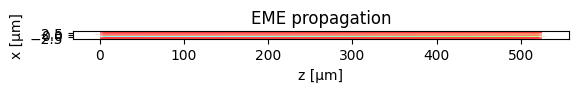

In [ ]:
#GAP = 1.4 um -> L_pi = 1.2 um

wg_gap = 1.4 
wg_width = 1.2 

d = wg_width + wg_gap
wg_N = 2

m = DC_EME() # Here you instantiate a Directional Coupler to be simulated with the Eigen-mode expansion (EME) algorithm.
m.MMI_num_modes = 12 # Number of modes to be calculated. Here, the higher, the better since we are going to calculate
                # the propagation based on the mode decomposition. 
m.DC_wg_gap = wg_gap # Gap between waveguides
m.DC_wg_width = wg_width # Width of the waveguides core
m.DC_N_waveguides = wg_N
m.find_all_modes()

L_pi =m.get_L_pi()

m.n_IN = 2
m.n_OUT = 2
m.L_MMI = L_pi/2 # Since we use the same library for propagation simulations of MMI and DC 
                    # some variables might be identified as "MMI". Sorry about that (: 
                    # Might change in the future 

# 4) Run propagation - get power transfer and plot propagation
m.propagation()
print(f"Gap: {wg_gap} um -> L_pi: {L_pi} um")

/home/mjulben/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)
/home/mjulben/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/14107 [00:00<?, ?it/s]

------- Pameters -------
MMI length 705.3304
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.7299
Total OUT power: 0.7217
Excess loss [dB] =  1.4167
------------------------
Power over OUTs:  ['0.3607', '0.3609']
Ratio over OUTs ['0.4999', '0.5001']
Gap: 1.5 um -> L_pi: 1410.660712373114 um


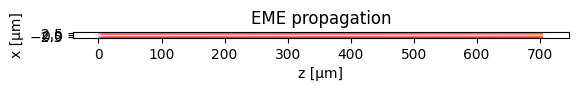

In [ ]:
#GAP = 1.5 um -> L_pi = 1.2 um

wg_gap = 1.5 
wg_width = 1.2 

d = wg_width + wg_gap
wg_N = 2

m = DC_EME() # Here you instantiate a Directional Coupler to be simulated with the Eigen-mode expansion (EME) algorithm.
m.MMI_num_modes = 12 # Number of modes to be calculated. Here, the higher, the better since we are going to calculate
                # the propagation based on the mode decomposition. 
m.DC_wg_gap = wg_gap # Gap between waveguides
m.DC_wg_width = wg_width # Width of the waveguides core
m.DC_N_waveguides = wg_N
m.find_all_modes()

L_pi =np.abs(m.get_L_pi())

m.n_IN = 2
m.n_OUT = 2
m.L_MMI = L_pi/2 # Since we use the same library for propagation simulations of MMI and DC 
                    # some variables might be identified as "MMI". Sorry about that (: 
                    # Might change in the future 

# 4) Run propagation - get power transfer and plot propagation
m.propagation()
print(f"Gap: {wg_gap} um -> L_pi: {L_pi} um")

/home/mjulben/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)
/home/mjulben/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/18925 [00:00<?, ?it/s]

------- Pameters -------
MMI length 946.2337
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.6724
Total OUT power: 0.6648
Excess loss [dB] =  1.7729
------------------------
Power over OUTs:  ['0.3327', '0.3321']
Ratio over OUTs ['0.5004', '0.4996']
Gap: 1.6 um -> L_pi: 1892.4674124163482 um


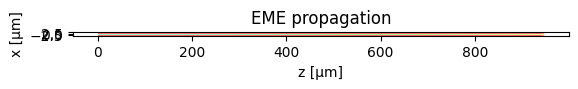

In [ ]:
#GAP = 1.6 um -> L_pi = 1.2 um

wg_gap = 1.6 
wg_width = 1.2 

d = wg_width + wg_gap
wg_N = 2

m = DC_EME() # Here you instantiate a Directional Coupler to be simulated with the Eigen-mode expansion (EME) algorithm.
m.MMI_num_modes = 12 # Number of modes to be calculated. Here, the higher, the better since we are going to calculate
                # the propagation based on the mode decomposition. 
m.DC_wg_gap = wg_gap # Gap between waveguides
m.DC_wg_width = wg_width # Width of the waveguides core
m.DC_N_waveguides = wg_N
m.find_all_modes()

L_pi =np.abs(m.get_L_pi())

m.n_IN = 2
m.n_OUT = 2
m.L_MMI = L_pi/2 # Since we use the same library for propagation simulations of MMI and DC 
                    # some variables might be identified as "MMI". Sorry about that (: 
                    # Might change in the future 

# 4) Run propagation - get power transfer and plot propagation
m.propagation()
print(f"Gap: {wg_gap} um -> L_pi: {L_pi} um")

/home/mjulben/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)
/home/mjulben/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)
/home/mjulben/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)
/home/mjulben/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)
/home/mjulben/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_for

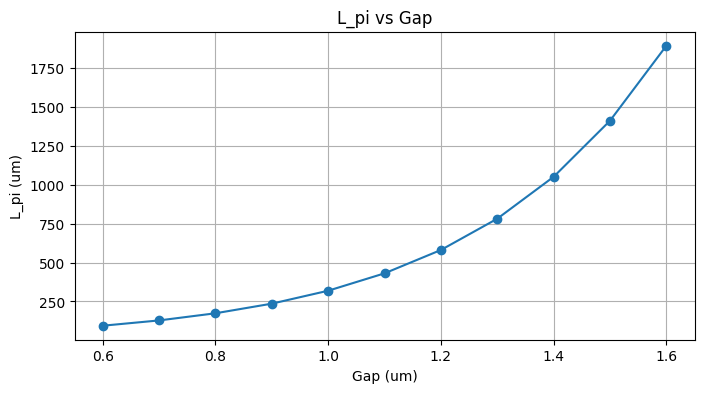

In [ ]:
# L_pi vs Gap

wg_gap = np.linspace(0.6, 1.6, 11)
wg_width = 1.2 

d = wg_width + wg_gap
wg_N = 2

L_pi_values = []

for gap in wg_gap:
    m = DC_EME()
    m.MMI_num_modes = 12
    m.DC_wg_gap = gap
    m.DC_wg_width = wg_width
    m.DC_N_waveguides = wg_N
    m.find_all_modes()
    L_pi_values.append(np.abs(m.get_L_pi()))

plt.figure(figsize=(8, 4))
plt.plot(wg_gap, L_pi_values, marker='o')
plt.xlabel("Gap (um)")
plt.ylabel("L_pi (um)")
plt.title("L_pi vs Gap")
plt.grid(True)
plt.show()

In [ ]:
#Si llego con Lpi, se acopla toda la luz en el puerto superior, por lo que es 0:100
#Si llego con Lpi/2, se acopla 50:50

## LO.3. Parallel uncoupled waveguides

In [ ]:
# HINT. Calculate manually the L_pi you may need to achieve K=0.1
# Then you can sweep the gap and calculate the L_pi until reaching 
# the desired value. 

DEDUCCIÓN MATEMÁTICA

Para determinar la longitud de batido ($L_\pi$) necesaria para limitar el acoplamiento inicial, partimos de las condiciones de diseño establecidas en el enunciado:

Longitud típica del chip ($L$): $10 mm$

Condición de acoplamiento objetivo manual ($K$): $0.1$ (es decir, un 10% de transferencia de potencia)

Partimos de la ecuación general del coeficiente de acoplamiento direccional:

$$K = \sin^2\left(\frac{\pi L}{2 L_\pi}\right)$$

Sustituimos los valores conocidos para encontrar el caso propuesto ($K = 0.1$):

$$0.1 = \sin^2\left(\frac{\pi \cdot 10000}{2 L_\pi}\right)$$

Despejamos $L_\pi$:

$$L_\pi = \frac{15707.96}{0.3217}$$
$$L_\pi \approx 48820 \mu m$$

**Conclusión:**
Para que dos guías paralelas que recorren una distancia de $10 mm$ en el chip limiten su transferencia de potencia al 10% ($K = 0.1$), la separación física (gap) entre ellas debe generar una longitud de batido de **$48820 \mu m$** (aproximadamente $4.88 cm$). Una vez comprobado esto, para alcanzar el verdadero desacoplo exigido posteriormente ($K < 0.01$), la separación deberá ser aún mayor, lo que implica buscar en la simulación gaps que generen un $L_\pi$ todavía más grande.

/home/mjulben/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)
/home/mjulben/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


Gap: 0.6 um -> L_pi: 58.77841253850998 um -> K: 0.0414275631644596


/home/mjulben/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)
/home/mjulben/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


Gap: 0.7 um -> L_pi: 78.41255344557842 um -> K: 0.4520074020704274


/home/mjulben/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)
/home/mjulben/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


...

/home/mjulben/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)
/home/mjulben/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


Gap: 1.5 um -> L_pi: -728.494235917582 um -> K: 0.17295936534599346


/home/mjulben/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


Gap: 1.6 um -> L_pi: 956.3405951460968 um -> K: 0.4319228211675429


/home/mjulben/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


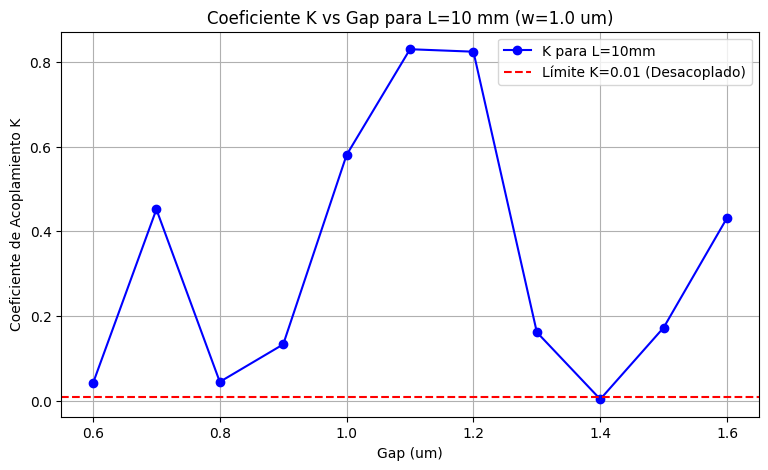

In [27]:
#GUIA DEEP

wg_width = 1.0 
L_chip = 10000 
wg_N = 2
wg_gap = np.linspace(0.6, 1.6, 11) 

L_pi_values = []
K_values = []

for gap in wg_gap:
    m = DC_EME()
    m.MMI_num_modes = 12
    m.DC_wg_gap = gap
    m.DC_wg_width = wg_width
    m.DC_N_waveguides = wg_N
    m.find_all_modes()
    
    L_pi = m.get_L_pi()
    L_pi_values.append(L_pi)
    
    K = np.sin((np.pi * L_chip) / (2 * L_pi))**2
    K_values.append(K)
    
    print(f"Gap: {gap} um -> L_pi: {L_pi} um -> K: {K}")


plt.figure(figsize=(9, 5))
plt.plot(wg_gap, K_values, 'o-', color='blue', label='K para L=10mm')

# Línea de referencia en K = 0.01
plt.axhline(0.01, color='red', linestyle='--', label='Límite K=0.01 (Desacoplado)')

#plt.yscale('log') # La escala logarítmica es clave aquí para ver bien el cruce
plt.xlabel("Gap (um)")
plt.ylabel("Coeficiente de Acoplamiento K")
plt.title("Coeficiente K vs Gap para L=10 mm (w=1.0 um)")
plt.grid(True)
plt.legend()
plt.show()

## LO.4. 2x2 Multimode Interference Coupler

### LO.4.1 Propagation Simulation

For the multimode interference (MMI) couplers we must rely on the design tables shown on the theoretical session: 

<img src="mmi.png" alt="Design tables for MMI couplers" width="600">

Here, you will use some functions provided by us (check **0. Imports** for more details) to simulate the propagation in a 2x2 directional coupler. Please read all the comments in the following code carefully and **make changes only to the lines marked with the #Student tag**

In [ ]:
#Vamos a hacer un ejemplo de paired
#Nosotros luego tenemos que hacer de Symmetric.
#Apareada toma los modos pares se ubican las entradas de manera que al propagar el modo, solo los paares se puedan propagar.

In [8]:
# Simulation flow for MMI Couplers
# Define your geometrical parameters here
mmi_Width = 6.6 # Student. Body width

m = MMI_EME() # Here you instantiate a MMI to be simulated with the Eigen-mode expansion (EME) algorithm.
m.MMI_width = mmi_Width
m.MMI_num_modes = 20 # Number of modes to be calculated. Here, the higher, the better since we are going to calculate
                    # the propagation based on the mode decomposition. 
                    #20 modos para la simulacion, si se consideran menos modos y son insuficientes pueden salir perdidas
                    #es por eso que se ponen muchos modos
# 1) Compute de MMI body modes - Only execute whenever a geometrical parameter is changed. Takes time to find the modes. 
m.find_all_modes()

# 2) Get the L_pi 
L_pi = m.get_L_pi()
print("L_pi = ", L_pi, " µm")

/home/mjulben/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  69.03598607257234  µm


/home/mjulben/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


In [ ]:
#PAREADA
#N es dos para comportamiento 2 a 2.
#buscamos el punto done hayan dos imagenes que es donde L_pi/2
#deberiamos encontrar que el campo se propaga y termina con dos imagenes iguales a la salida

  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/690 [00:00<?, ?it/s]

------- Pameters -------
MMI length 34.5180
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.9604
Total OUT power: 0.9075
Excess loss [dB] =  0.4217
------------------------
Power over OUTs:  ['0.4675', '0.4399']
Ratio over OUTs ['0.5152', '0.4848']
L_pi: 69.03598607257234 µm
λ = 1.55 µm
MMI Body Width: 6.6 µm
L_MMI (Design): 34.51799303628617 µm = L_pi/2


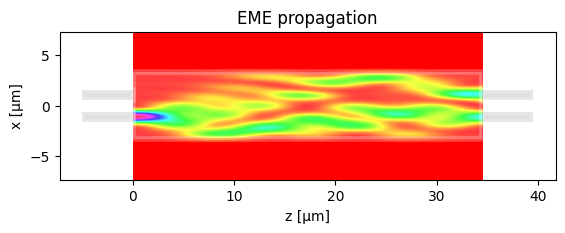

In [9]:
# IMPORTANT!!! 
# # If you DON'T change neither the MMI width 
# nor input/output waveguide widths
# YOU CAN RUN the lines below as many times as you wish
# (SAVES TIME)

# 3) Configure MMI
# # MMI I/O number (check class slides for type of MMI)
m.n_IN = 2 # STUDENT
m.n_OUT = 2 # STUDENT

# MMI I/O waveguide positions (check class slides for type of MMI)
m.IN_WVG_positions = mmi_Width*np.array([-1/6,1/6]) # STUDENT
m.OUT_WVG_positions = mmi_Width*np.array([-1/6,1/6]) # STUDENT

# MMI length (check class slides for type of MMI)
m.L_MMI = (1/2)*L_pi # STUDENT

# Run propagation
m.propagation()

print(f"L_pi: {L_pi} µm")
print("λ = 1.55 µm")
print(f"MMI Body Width: {mmi_Width} µm")
print(f"L_MMI (Design): {m.L_MMI} µm = L_pi/2")


### LO.4.2. 2x2 Multimode Interference Coupler - Optimization

  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/682 [00:00<?, ?it/s]

------- Pameters -------
MMI length 34.5180
MMI length increment -0.4000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.9571
Total OUT power: 0.9159
Excess loss [dB] =  0.3815
------------------------
Power over OUTs:  ['0.4652', '0.4507']
Ratio over OUTs ['0.5080', '0.4920']

 Con dL_MMI = -0.4 | dy = 0.05


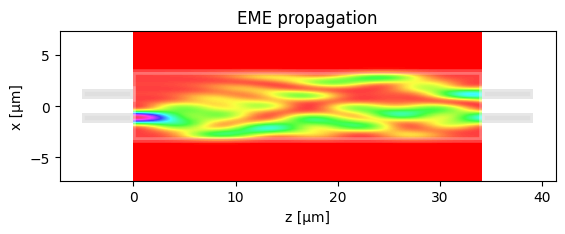

In [16]:
dy = 0.05

# MMI I/O waveguide positions (check class slides for type of MMI)
#se crea un arreglo donde a la guia inferiror le restamos dy y a la superior se lo sumamos para sempararlas
m.IN_WVG_positions = mmi_Width*np.array([-1/6,1/6]) + np.array([-dy,dy]) # STUDENT
m.OUT_WVG_positions = mmi_Width*np.array([-1/6,1/6]) + np.array([-dy,dy]) # STUDENT

#PRIMERO: añadir dy
#SEGUNDO: modificar el MMI leghth aum o dismin. para mejorar perdidas
#TERCERO: ajustar dy

# MMI length (check class slides for type of MMI)
#m.dL_MMI = 2 # STUDENT, hay perdidias de 1.18, tocara separarlas menos
m.dL_MMI = -0.4 # STUDENT, se consigue mejorar la relacion de acoplo porque las Losses DB son 0.49
#el dy=0 pero ahora vamos aa ajustarlo para mejorar las perdidas por exceso con dy=-0.01. Incluso mejor con dy=0

# Run propagation
m.propagation()
print(f"\n Con dL_MMI = {m.dL_MMI} | dy = {dy}")


 Probando dL_MMI = -0.6 | dy = -0.025 ---


  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/678 [00:00<?, ?it/s]

------- Pameters -------
MMI length 34.5180
MMI length increment -0.6000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.9624
Total OUT power: 0.8944
Excess loss [dB] =  0.4849
------------------------
Power over OUTs:  ['0.4548', '0.4396']
Ratio over OUTs ['0.5085', '0.4915']

 Probando dL_MMI = -0.6 | dy = -0.5 ---


  0%|          | 0/7 [00:00<?, ?it/s]

...

  0%|          | 0/682 [00:00<?, ?it/s]

------- Pameters -------
MMI length 34.5180
MMI length increment -0.4000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.9593
Total OUT power: 0.9130
Excess loss [dB] =  0.3951
------------------------
Power over OUTs:  ['0.4647', '0.4484']
Ratio over OUTs ['0.5089', '0.4911']

 Probando dL_MMI = -0.4 | dy = 0.05 ---


  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/682 [00:00<?, ?it/s]

------- Pameters -------
MMI length 34.5180
MMI length increment -0.4000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.9571
Total OUT power: 0.9159
Excess loss [dB] =  0.3815
------------------------
Power over OUTs:  ['0.4652', '0.4507']
Ratio over OUTs ['0.5080', '0.4920']


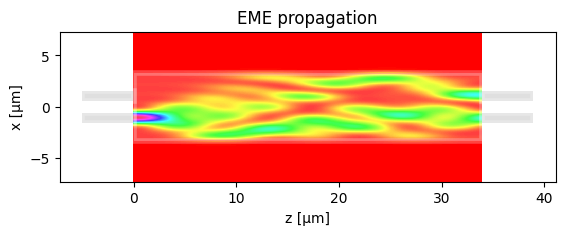

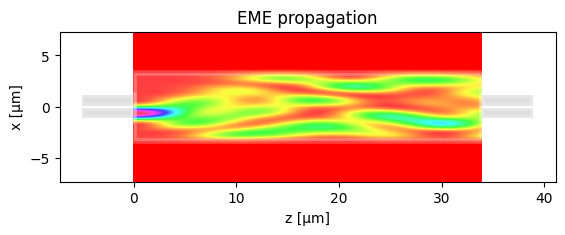

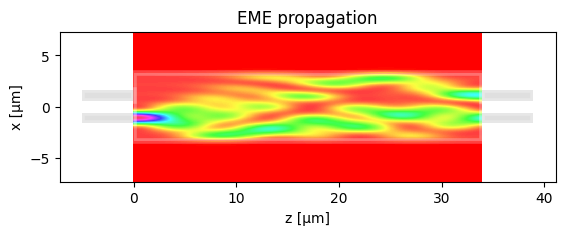

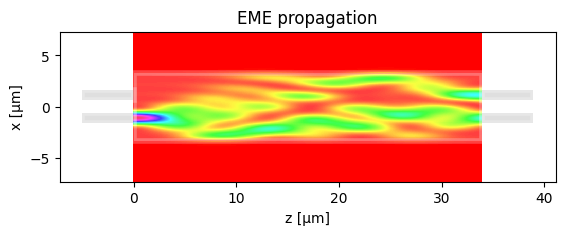

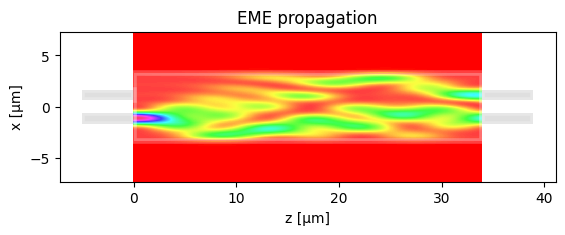

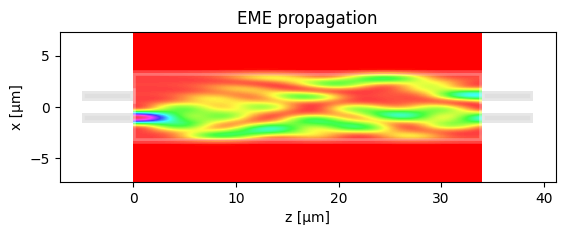

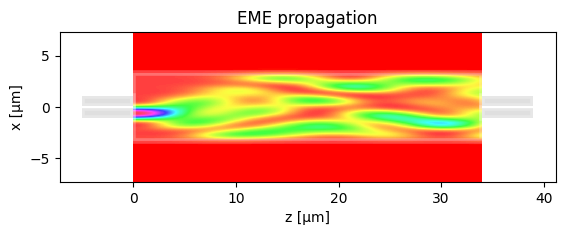

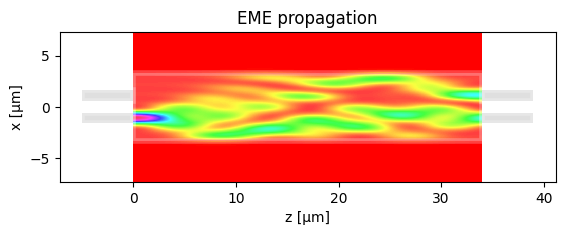

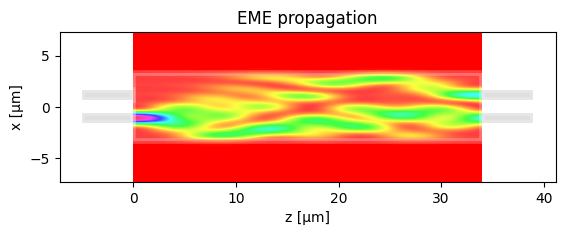

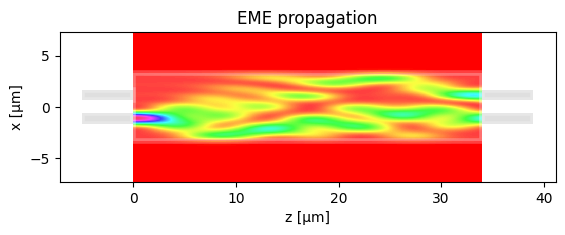

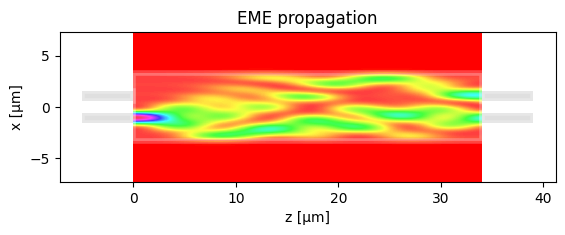

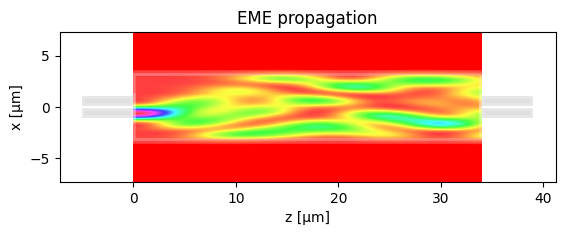

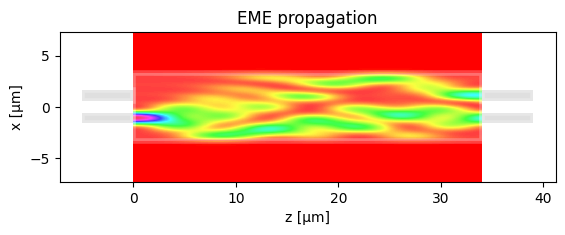

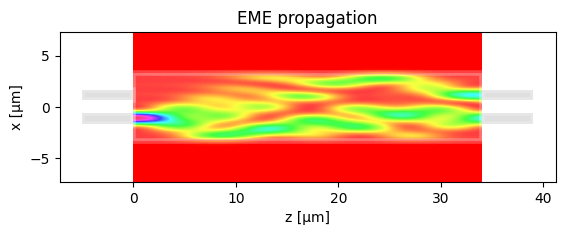

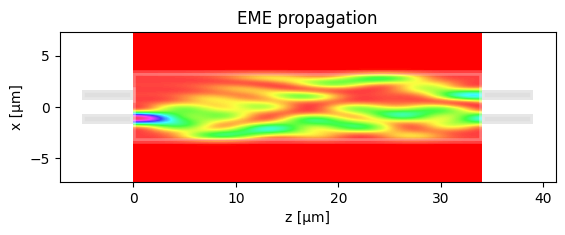

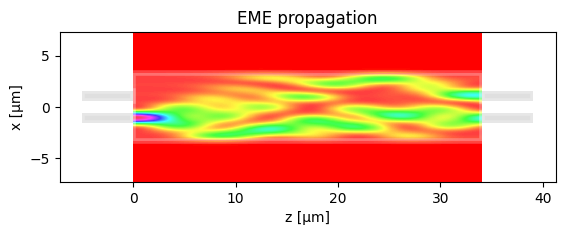

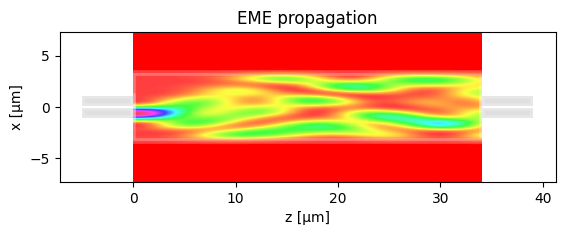

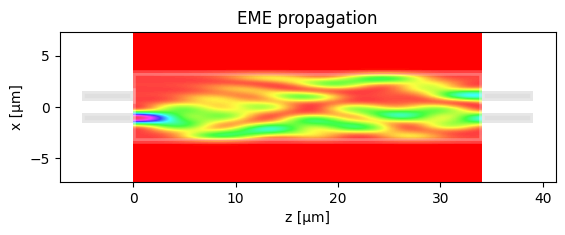

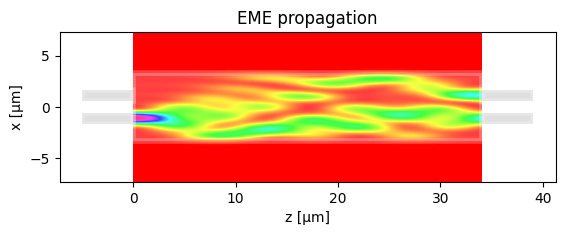

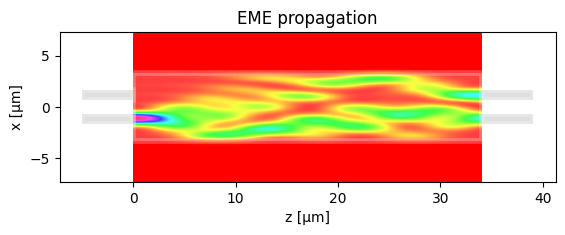

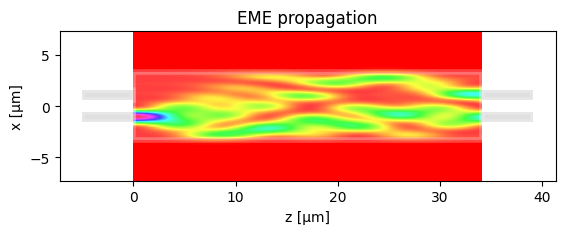

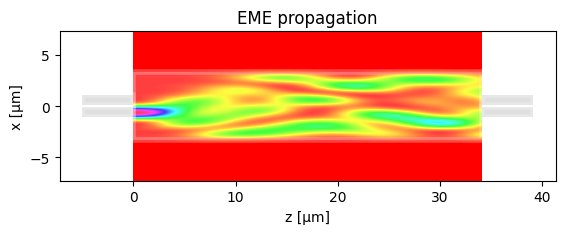

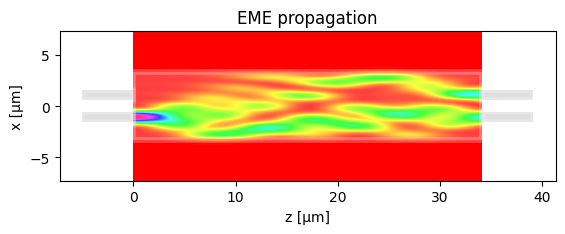

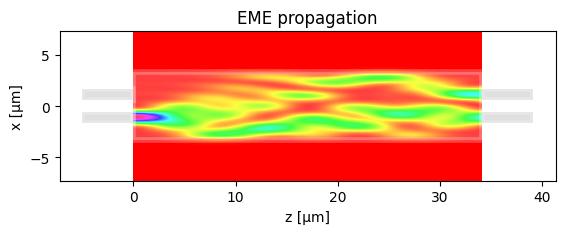

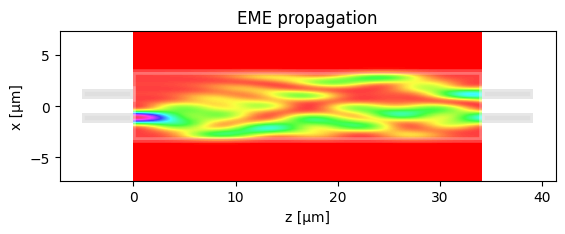

In [ ]:
d_lengths = [-0.6, -0.55, -0.5, -0.45, -0.4] 
d_positions = [-0.025, -0.5, 0.0, 0.025, 0.05]

for dl in d_lengths:
    for dy in d_positions:
        print(f"\n Con dL_MMI = {dl} | dy = {dy} ---")
        
        m.IN_WVG_positions = mmi_Width*np.array([-1/6,1/6]) + np.array([-dy,dy])
        m.OUT_WVG_positions = mmi_Width*np.array([-1/6,1/6]) + np.array([-dy,dy])
        
        m.dL_MMI = dl
        
        m.propagation()

### LO.4.3 2x2 Multimode Interference Coupler – Optimization (II)

In [19]:
# Design flow for MMI

m = MMI_EME()
m.MMI_width = 6.6   # MMI width
m.wg_width_dw = 1.0 # STUDENT

# 1) Compute de MMI modes
m.find_all_modes()

# 2) Get the L_pi
L_pi = m.get_L_pi()
print("L_pi = ", L_pi, " µm")

/home/mjulben/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  69.03598607254776  µm


/home/mjulben/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/682 [00:00<?, ?it/s]

------- Pameters -------
MMI length 34.5180
MMI length increment -0.4000
IO wg width 1.0000
IO wg width increment 1.0000
------------------------
Total power IN coupled 0.9984
Total OUT power: 0.9966
Excess loss [dB] =  0.0150
------------------------
Power over OUTs:  ['0.5087', '0.4878']
Ratio over OUTs ['0.5105', '0.4895']


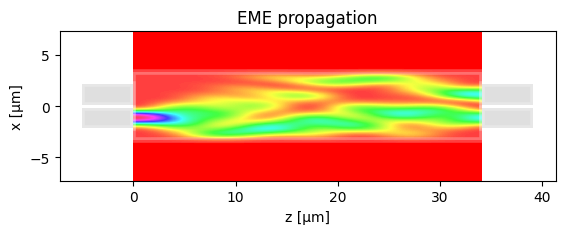

In [20]:
# 3) Configure MMI
# # MMI I/O number (check class slides for type of MMI)
m.n_IN = 2 # STUDENT
m.n_OUT = 2 # STUDENT

dy = 0.05
# MMI I/O waveguide positions (check class slides for type of MMI)
m.IN_WVG_positions = mmi_Width*np.array([-1/6,1/6]) + np.array([-dy,dy]) # STUDENT
m.OUT_WVG_positions = mmi_Width*np.array([-1/6,1/6]) + np.array([-dy,dy]) # STUDENT

# MMI length (check class slides for type of MMI)
m.L_MMI = 1/2*L_pi  # STUDENT
m.dL_MMI = -0.4 # STUDENT

# Run propagation
m.propagation()


--- Incremento de ancho I/O wg_width_dw = 0.6 um ---


/home/mjulben/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)
/home/mjulben/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/682 [00:00<?, ?it/s]

------- Pameters -------
MMI length 34.5180
MMI length increment -0.4000
IO wg width 1.0000
IO wg width increment 0.6000
------------------------
Total power IN coupled 0.9894
Total OUT power: 0.9780
Excess loss [dB] =  0.0964
------------------------
Power over OUTs:  ['0.4982', '0.4798']
Ratio over OUTs ['0.5094', '0.4906']

--- Incremento de ancho I/O wg_width_dw = 0.7 um ---


...

------- Pameters -------
MMI length 34.5180
MMI length increment -0.4000
IO wg width 1.0000
IO wg width increment 1.3000
------------------------
Total power IN coupled 0.9997
Total OUT power: 1.0008
Excess loss [dB] =  -0.0034
------------------------
Power over OUTs:  ['0.5113', '0.4895']
Ratio over OUTs ['0.5109', '0.4891']

--- Incremento de ancho I/O wg_width_dw = 1.4 um ---


/home/mjulben/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)
/home/mjulben/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/682 [00:00<?, ?it/s]

------- Pameters -------
MMI length 34.5180
MMI length increment -0.4000
IO wg width 1.0000
IO wg width increment 1.4000
------------------------
Total power IN coupled 0.9998
Total OUT power: 1.0020
Excess loss [dB] =  -0.0087
------------------------
Power over OUTs:  ['0.5119', '0.4901']
Ratio over OUTs ['0.5109', '0.4891']


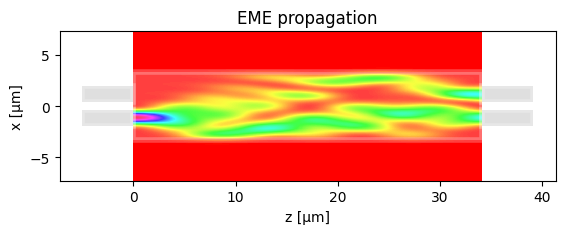

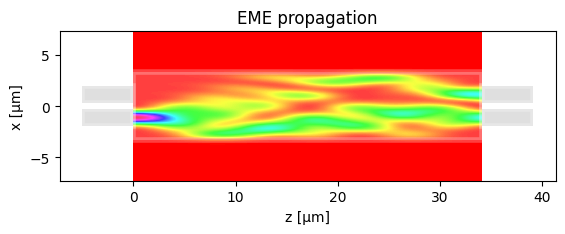

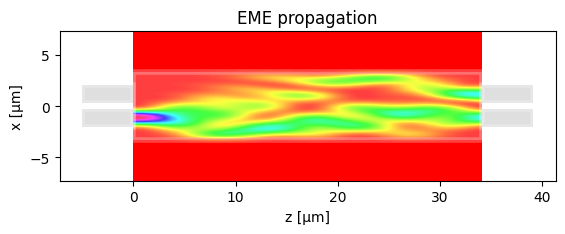

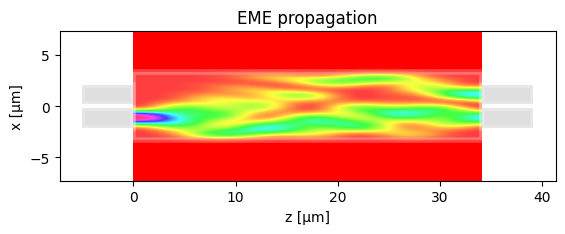

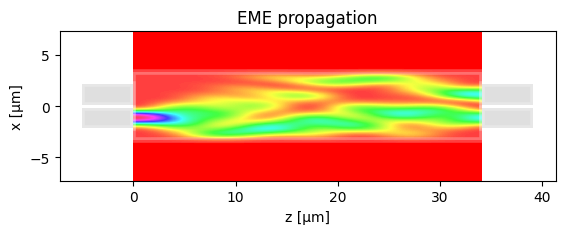

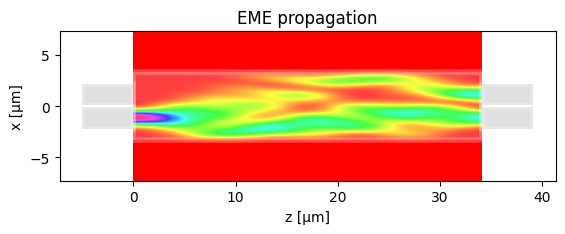

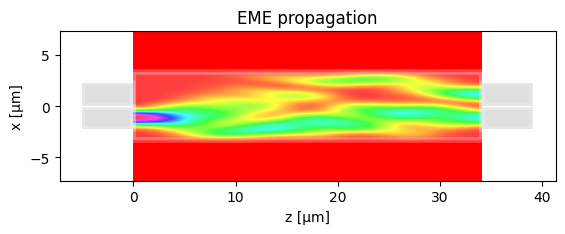

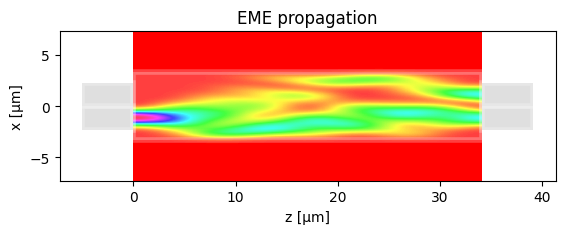

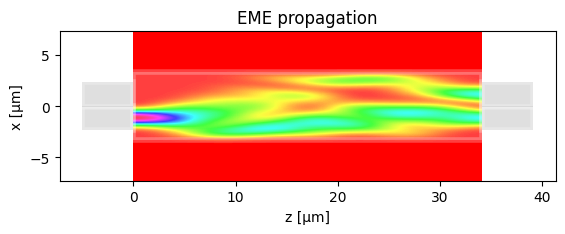

In [18]:
anchos_extra_a_probar = [0.6, 0.7,0.8,0.9,1.0,1.1,1.2,1.3,1.4]
mmi_Width = 6.6

for dw in anchos_extra_a_probar:
    print(f"\n--- Incremento de ancho I/O wg_width_dw = {dw} um ---")
    
    m = MMI_EME()
    m.MMI_width = mmi_Width
    m.wg_width_dw = dw 
    
    m.find_all_modes()
    L_pi = m.get_L_pi()
    
    m.n_IN = 2 
    m.n_OUT = 2 
    
    dy = 0.05
    m.IN_WVG_positions = mmi_Width*np.array([-1/6,1/6]) + np.array([-dy,dy]) 
    m.OUT_WVG_positions = mmi_Width*np.array([-1/6,1/6]) + np.array([-dy,dy]) 
    
    m.L_MMI = 1/2 * L_pi 
    m.dL_MMI = -0.4
    
    m.propagation()

## LO.5. 1x4 1x4 Multimode Interference Coupler 

Repeat the design procedure explained for the 2x2 Coupler to design a 1x4 MMI Coupler. Consider: 
- Select a suitable MMI body width, taking into account that you now must allocate 4 waveguides at the output. 
- Minimize the losses and output imbalance for the MMI coupler. 

/home/mjulben/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi calculado = 263.95027837534934 µm


/home/mjulben/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/14 [00:00<?, ?it/s]

  0%|          | 0/990 [00:00<?, ?it/s]

------- Pameters -------
MMI length 49.4907
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.9480
Total OUT power: 0.8297
Excess loss [dB] =  0.8108
------------------------
Power over OUTs:  ['0.2114', '0.2035', '0.2034', '0.2114']
Ratio over OUTs ['0.2548', '0.2453', '0.2452', '0.2548']
L_pi=263.95027837534934 µm, L_MMI=49.490677195378 µm, MMI Width=13.2 µm


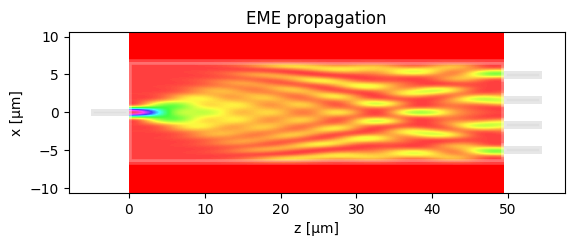

In [4]:
mmi_Width = 13.2

m = MMI_EME()
m.MMI_width = mmi_Width
m.wg_width_dw = 0.0 
m.MMI_num_modes = 30 


m.find_all_modes()
L_pi = m.get_L_pi()
print(f"L_pi calculado = {L_pi} µm")

m.n_IN = 1
m.n_OUT = 4


m.IN_WVG_positions = np.array([0.0]) 
m.OUT_WVG_positions = mmi_Width * np.array([-3/8, -1/8, 1/8, 3/8])

m.L_MMI = (3/16) * L_pi 
m.dL_MMI = 0.0 

m.propagation()

print(f"L_pi={L_pi} µm, L_MMI={m.L_MMI} µm, MMI Width={mmi_Width} µm")

  0%|          | 0/14 [00:00<?, ?it/s]

  0%|          | 0/964 [00:00<?, ?it/s]

------- Pameters -------
MMI length 49.4907
MMI length increment -1.3000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.9480
Total OUT power: 0.8947
Excess loss [dB] =  0.4834
------------------------
Power over OUTs:  ['0.2353', '0.2121', '0.2120', '0.2353']
Ratio over OUTs ['0.2630', '0.2370', '0.2370', '0.2630']

 Con dL_MMI = -1.3 | dy = 0.1
L_pi=263.95027837534934 µm, L_MMI=49.490677195378 µm, MMI Width=13.2 µm


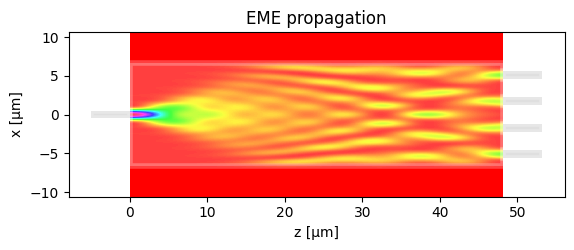

In [20]:
dl = -1.3
#dw = 0.35
dy=0.1

m.n_IN = 1
m.n_OUT = 4

m.IN_WVG_positions = np.array([0.0]) 
m.OUT_WVG_positions = (mmi_Width) * np.array([-3/8, -1/8, 1/8, 3/8]) + np.array([-1.5*dy, -0.5*dy, 0.5*dy, 1.5*dy])

m.L_MMI = (3/16) * L_pi 
m.dL_MMI = dl

m.propagation()
print(f"\n Con dL_MMI = {dl} | dy = {dy}")
print(f"L_pi={L_pi} µm, L_MMI={m.L_MMI} µm, MMI Width={mmi_Width} µm")


 Incremento de ancho I/O wg_width_dw = 1.5 um


/home/mjulben/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)
/home/mjulben/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/12 [00:00<?, ?it/s]

  0%|          | 0/964 [00:00<?, ?it/s]

------- Pameters -------
MMI length 49.4907
MMI length increment -1.3000
IO wg width 1.0000
IO wg width increment 1.5000
------------------------
Total power IN coupled 0.9975
Total OUT power: 0.9940
Excess loss [dB] =  0.0262
------------------------
Power over OUTs:  ['0.2437', '0.2533', '0.2533', '0.2437']
Ratio over OUTs ['0.2452', '0.2548', '0.2548', '0.2452']
L_pi=263.9502783755689 µm, L_MMI=49.490677195419174 µm, MMI Width=13.2 µm


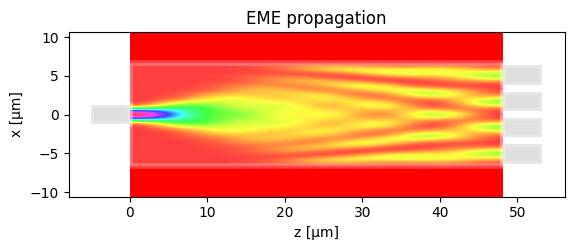

In [25]:
dw = 1.5

mmi_Width = 13.2

print(f"\n Incremento de ancho I/O wg_width_dw = {dw} um")

m = MMI_EME()
m.MMI_width = mmi_Width
m.wg_width_dw = dw 

m.find_all_modes()
L_pi = m.get_L_pi()

m.n_IN = 1
m.n_OUT = 4

dy = 0.1
m.IN_WVG_positions = np.array([0.0]) 
m.OUT_WVG_positions = (mmi_Width) * np.array([-3/8, -1/8, 1/8, 3/8]) + np.array([-1.5*dy, -0.5*dy, 0.5*dy, 1.5*dy])

m.L_MMI = (3/16) * L_pi 
m.dL_MMI = -1.3

m.propagation()
print(f"L_pi={L_pi} µm, L_MMI={m.L_MMI} µm, MMI Width={mmi_Width} µm")

## Extra - Exercises

### E1. Directional coupler gap dependence

In [ ]:
gap_to_simulate = 600 * nm # STUDENT. You can manually change the gap
                            # or you can sweep the parameter using a Python for loop. 

deep_dcoupler_cs = gt.modes.WaveguideCoupler(
    wavelength=wavelength, # Wavelength to simulate - Must be a vector
    core_width=(1.0, 1.0), # Waveguide width
    gap=gap_to_simulate,
    slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguide.
    core_material='sin', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    core_thickness=300 * nm, # Waveguide height 
    num_modes=4, # Number of modes to find
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
    max_grid_scaling=1.5, # Parameters of the grid
    grid_resolution=20 # Parameters of the grid
)

# STUDENT. Plot goes here


### E2. Directional coupler wavelength dependence

In [ ]:
wavelength = ... # STUDENT code goes here

deep_dcoupler_cs = gt.modes.WaveguideCoupler(
    wavelength=wavelength, # Wavelength to simulate - Must be a vector
    core_width=(1.0, 1.0), # Waveguide width
    gap=600 * nm,
    slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguide.
    core_material='sin', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    core_thickness=300 * nm, # Waveguide height 
    num_modes=4, # Number of modes to find
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
    max_grid_scaling=1.5, # Parameters of the grid
    grid_resolution=20 # Parameters of the grid
)

deep_neff = deep_dcoupler_cs.n_eff
L_pi_TE = ... # STUDENT code here

plt.figure(figsize=(10, 5))
plt.scatter(wavelength, L_pi_TE,edgecolors='k',facecolors='none',label = '__nolegend__')
plt.plot(wavelength, L_pi_TE,label='Deep')
plt.xlabel("Wavelength (um)")
plt.ylabel("L_pi")
plt.grid()
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout(rect=[0, 0, 0.85, 1])

ValidationError: 1 validation error for WaveguideCoupler
wavelength
  float() argument must be a string or a real number, not 'ellipsis' (type=type_error)

### E3. MMI coupler wavelength dependence

In [ ]:
mmi_body_w = 6.6 
lambda_c = ... # STUDENT code goes here.

mmi_body_waveguide = gt.modes.Waveguide(
    # Geometrical Parameters
    core_width=mmi_body_w, # MMI Body width
    core_thickness=300 * nm, # MMI Body height 
    slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguides.
    # Materials
    core_material='sin', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    # Modesolver Parameters
    wavelength=lambda_c, # Wavelength to simulate
    num_modes=15, # Targeted number of modes to find - Higher than before! It's a multimode section
    max_grid_scaling=1.5, # Parameters of the grid
    grid_resolution=20, # Parameters of the grid
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
)

d_n_eff = mmi_body_waveguide.n_eff[0].real -  mmi_body_waveguide.n_eff[1].real

L_pi = ... # STUDENT code goes here

# STUDENT plot here. 

### E4. MMI coupler body width dependence

In [ ]:
lambda_c = 1.55

mmi_body_w = 6.6 # STUDENT. You can manually change the body width
                 # or you can sweep the parameter using a Python for loop. 

mmi_body_waveguide = gt.modes.Waveguide(
    # Geometrical Parameters
    core_width=mmi_body_w, # MMI Body width
    core_thickness=300 * nm, # MMI Body height 
    slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguides.
    # Materials
    core_material='sin', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    # Modesolver Parameters
    wavelength=lambda_c, # Wavelength to simulate
    num_modes=15, # Targeted number of modes to find - Higher than before! It's a multimode section
    max_grid_scaling=1.5, # Parameters of the grid
    grid_resolution=20, # Parameters of the grid
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
)

d_n_eff = mmi_body_waveguide.n_eff[0].real -  mmi_body_waveguide.n_eff[1].real

L_pi = ... # STUDENT code goes here

# STUDENT plot here. 